# گزارش نهایی مسئلهٔ ۱: تشخیص تصادف از ویدئو

این نوت‌بوک خروجی مراحل آماده‌سازی داده، مدل‌سازی و ارزیابی را برای ارائهٔ پروژه جمع‌بندی می‌کند.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score

DATA_ROOT = Path(r'P:\NexarCollisionData')
MODEL_DIR = DATA_ROOT / 'models'
selected = pd.read_csv(DATA_ROOT / 'selected_train_600.csv')
video_splits = pd.read_csv(DATA_ROOT / 'video_splits.csv')
frame_index = pd.read_csv(DATA_ROOT / 'frame_index.csv')

print('Selected videos by class:')
print(selected['label'].value_counts().sort_index())
print('\nFrames extracted:', len(frame_index))

Selected videos by class:
label
0    300
1    300
Name: count, dtype: int64

Frames extracted: 4800


In [2]:
split_counts = pd.crosstab(video_splits['split'], video_splits['label'])
split_counts.columns = ['negative (0)', 'positive (1)']
split_counts

,negative (0),positive (1)
split,,
train,240,240
validation,60,60


## روش آماده‌سازی

- برچسب ویدئو از وجود/عدم‌وجود `time_of_event` ساخته شد.
- برای نسخهٔ اولیه، ۳۰۰ ویدئوی مثبت و ۳۰۰ ویدئوی منفی انتخاب شد.
- از هر ویدئو، ۸ فریم با فاصلهٔ یکنواخت استخراج و به 224×224 تبدیل شد.
- تقسیم داده در سطح ویدئو به‌صورت stratified انجام شد: ۴۸۰ train و ۱۲۰ validation.

In [3]:
baseline = pd.read_csv(MODEL_DIR / 'resnet18_validation_predictions.csv')
threshold_predictions = pd.read_csv(MODEL_DIR / 'resnet18_validation_predictions_with_threshold.csv')
gru = pd.read_csv(MODEL_DIR / 'resnet18_gru_validation_predictions.csv')
with (MODEL_DIR / 'resnet18_decision_threshold.json').open(encoding='utf-8') as file:
    selected_threshold = json.load(file)['threshold']

baseline_default = baseline['prediction']
baseline_f1_threshold = threshold_predictions['prediction_at_best_f1_threshold']
gru_default = gru['prediction']

comparison = pd.DataFrame([
    {
        'model': 'ResNet18 frame baseline (threshold=0.50)',
        'f1': f1_score(baseline['label'], baseline_default),
        'accuracy': accuracy_score(baseline['label'], baseline_default),
    },
    {
        'model': f'ResNet18 frame baseline (threshold={selected_threshold:.2f})',
        'f1': f1_score(threshold_predictions['label'], baseline_f1_threshold),
        'accuracy': accuracy_score(threshold_predictions['label'], baseline_f1_threshold),
    },
    {
        'model': 'ResNet18 feature encoder + GRU (threshold=0.50)',
        'f1': f1_score(gru['label'], gru_default),
        'accuracy': accuracy_score(gru['label'], gru_default),
    },
])
comparison.sort_values('f1', ascending=False).reset_index(drop=True)

,model,f1,accuracy
0,ResNet18 frame baseline (threshold=0.35),0.729560,0.641667
1,ResNet18 frame baseline (threshold=0.50),0.681481,0.641667
2,ResNet18 feature encoder + GRU (threshold=0.50),0.655738,0.650000


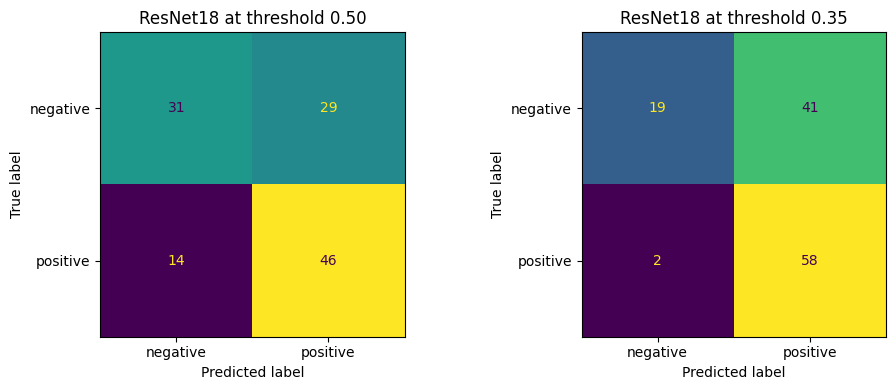

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(baseline['label'], baseline_default), display_labels=['negative', 'positive']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('ResNet18 at threshold 0.50')
ConfusionMatrixDisplay(confusion_matrix(threshold_predictions['label'], baseline_f1_threshold), display_labels=['negative', 'positive']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'ResNet18 at threshold {selected_threshold:.2f}')
plt.tight_layout()

## نتیجه‌گیری

مدل منتخب ResNet18 fine-tune‌شده است. در آستانهٔ ۰.۵، توازن محافظه‌کارانه‌تری میان هشدار اشتباه و تصادفِ ازدست‌رفته دارد. آستانهٔ انتخاب‌شده با validation برای بیشینه‌سازی F1 پایین‌تر است و recall بالاتری دارد، اما هشدار اشتباه بیشتری می‌دهد.

برای پیش‌بینی ویدئوی جدید از نوت‌بوک `05_final_video_inference.ipynb` استفاده می‌کنیم.